In [1]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate

#from test_utils import summary, comparator

In [2]:
import os
import shutil
import random

# Define paths
image_folder = "/Users/kakumanisravya/Desktop/project/CameraRGB/"
mask_folder = "/Users/kakumanisravya/Desktop/project/CameraMask/"
train_folder = "/Users/kakumanisravya/Desktop/project/train/"
test_folder = "/Users/kakumanisravya/Desktop/project/test/"

# Create directories if they don't exist
os.makedirs(os.path.join(train_folder, "Images"), exist_ok=True)
os.makedirs(os.path.join(train_folder, "Masks"), exist_ok=True)
os.makedirs(os.path.join(test_folder, "Images"), exist_ok=True)
os.makedirs(os.path.join(test_folder, "Masks"), exist_ok=True)



image_filenames = [filename for filename in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, filename))]
mask_filenames = [filename for filename in os.listdir(mask_folder) if os.path.isfile(os.path.join(mask_folder, filename))]

# Define proportions for train and test sets
train_split = 0.8
test_split = 0.2

# Calculate number of images for each set
num_images = len(image_filenames)
num_train = int(train_split * num_images)
num_test = num_images - num_train

# Split filenames into train and test sets
train_image_filenames = image_filenames[:num_train]
test_image_filenames = image_filenames[num_train:]

train_mask_filenames = mask_filenames[:num_train]
test_mask_filenames = mask_filenames[num_train:]

# Copy images and masks to train folder
for img_filename, mask_filename in zip(train_image_filenames, train_mask_filenames):
    shutil.copy(os.path.join(image_folder, img_filename), os.path.join(train_folder, "Images", img_filename))
    shutil.copy(os.path.join(mask_folder, mask_filename), os.path.join(train_folder, "Masks", mask_filename))

# Copy images and masks to test folder
for img_filename, mask_filename in zip(test_image_filenames, test_mask_filenames):
    shutil.copy(os.path.join(image_folder, img_filename), os.path.join(test_folder, "Images", img_filename))
    shutil.copy(os.path.join(mask_folder, mask_filename), os.path.join(test_folder, "Masks", mask_filename))
    
    
train_image_filenames = [train_folder+"Images/"+i for i in train_image_filenames]
test_image_filenames = [test_folder+"Images/"+i for i in test_image_filenames]

train_mask_filenames = [train_folder+"Masks/"+i for i in train_mask_filenames]
test_mask_filenames = [test_folder+"Masks/"+i for i in test_mask_filenames]

In [3]:
train_dataset=tf.data.Dataset.from_tensor_slices((train_image_filenames,train_mask_filenames))
test_dataset=tf.data.Dataset.from_tensor_slices((test_image_filenames,test_mask_filenames))

In [4]:
def process_path(image_path, mask_path):
    print(image_path)
    print(mask_path)
    img = tf.io.read_file(image_path)
    print(img)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.math.reduce_max(mask, axis=-1, keepdims=True)
    return img, mask

def preprocess(image, mask):
    input_image = tf.image.resize(image, (96, 128), method='nearest')
    input_mask = tf.image.resize(mask, (96, 128), method='nearest')

    input_image = input_image / 255.

    return input_image, input_mask

train_image_ds = train_dataset.map(process_path)
train_processed_image_ds = train_image_ds.map(preprocess)
test_image_ds = test_dataset.map(process_path)
test_processed_image_ds = test_image_ds.map(preprocess)

Tensor("args_0:0", shape=(), dtype=string)
Tensor("args_1:0", shape=(), dtype=string)
Tensor("ReadFile:0", shape=(), dtype=string)
Tensor("args_0:0", shape=(), dtype=string)
Tensor("args_1:0", shape=(), dtype=string)
Tensor("ReadFile:0", shape=(), dtype=string)


In [5]:
#defining a convblock method which has 2 conv block a variable dropout and maxpooling 
def conv_block(inputs=None, n_filters=32, dropout_prob=0, max_pooling=True):
    conv = Conv2D(n_filters,3,activation='relu',padding='same',kernel_initializer='he_normal')(inputs)
    conv = Conv2D(n_filters,3,activation='relu',padding='same',kernel_initializer='he_normal')(conv)
   
    if dropout_prob > 0:
        conv = Dropout(rate=dropout_prob)(conv)
    if max_pooling:
        next_layer = MaxPooling2D(2,2)(conv)
    else:
        next_layer = conv
    skip_connection = conv
    
    return next_layer, skip_connection

In [6]:
"""
        upsampling block
        expansive_input -- Input tensor from previous layer
        contractive_input -- Input tensor from previous skip layer
        conv -- Tensor output
    """
def upsampling_block(expansive_input, contractive_input, n_filters=32):
    up = Conv2DTranspose(n_filters,3,strides=2,padding='same')(expansive_input)
    # Merge the previous output and the skiplayer 
    merge = concatenate([up, contractive_input], axis=3)
    conv = Conv2D(n_filters,3,activation='relu',padding='same',kernel_initializer='he_normal')(merge)
    conv = Conv2D(n_filters,3,activation='relu',padding='same',kernel_initializer='he_normal')(conv)
    return conv

In [7]:
def unet_model(input_size=(96, 128, 3), n_filters=32, n_classes=23):
    inputs = Input(input_size)

    #Contracting path (encoding)
    cblock1 = conv_block(inputs, n_filters)
    # output of each block to be the input of the next block.
    # Double the number of filters at each new step
    cblock2 = conv_block(cblock1[0], n_filters*2)
    cblock3 = conv_block(cblock2[0], n_filters*4)
    cblock4 = conv_block(cblock3[0], n_filters*8, dropout_prob=0.3)
    cblock5 = conv_block(cblock4[0],  n_filters*16, dropout_prob=0.3, max_pooling=False)

    # Expanding Path (decoding)
    # Use the cblock5[0] is expansive_input and cblock4[1] is contractive_input
    ublock6 = upsampling_block(cblock5[0], cblock4[1],  n_filters * 8)
    #half the number of filters of the previous block
    ublock7 = upsampling_block(ublock6, cblock3[1], n_filters * 4)
    ublock8 = upsampling_block(ublock7, cblock2[1], n_filters * 2)
    ublock9 = upsampling_block(ublock8, cblock1[1], n_filters)

    conv9 = Conv2D(n_filters,3,activation='relu',padding='same',kernel_initializer='he_normal')(ublock9)
    conv10 = Conv2D(n_classes, 1, padding='same')(conv9)
    model = tf.keras.Model(inputs=inputs, outputs=conv10)

    return model

In [8]:
unet = unet_model((96,128,3),32,23)
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 128,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 128,   │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 12, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 16,    │          0 │ conv2d_7[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 8, 256) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 6, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 12, 16,    │  1,179,904 │ dropout_1[0][0] 

 Total params: 8,640,471 (32.96 MB)

 Trainable params: 8,640,471 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
unet.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:

train_dataset = train_processed_image_ds.cache().batch(32)
print(train_processed_image_ds.element_spec)
model_history = unet.fit(train_dataset, epochs=40)

(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.1891 - loss: 3.5632
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.4318 - loss: 2.0501
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4661 - loss: 1.5028
Epoch 4/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7512 - loss: 1.0271
Epoch 5/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7534 - loss: 0.8712
Epoch 6/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 4365s 168s/step - accuracy: 0.7560 - loss: 0.7974
Epoch 7/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1863s 72s/step - accuracy: 0.7639 - loss: 0.7646
Epoch 8/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7751 - loss: 0.7333
Epoch 9/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7884 - loss: 0.6859
Epoch 10/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8011 - loss: 0.6262
Epoch 11/40
27/27 ━━━━━━━━━━━━━

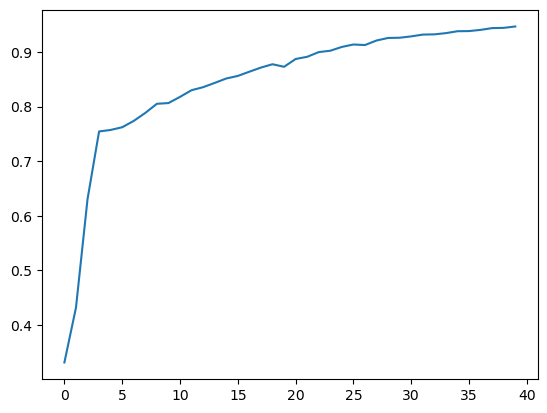

In [47]:
import matplotlib.pyplot as plt
plt.plot(model_history.history["accuracy"])

In [48]:
test_dataset = test_processed_image_ds.cache().batch(32)
test_loss, test_accuracy = unet.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 480ms/step - accuracy: 0.9376 - loss: 0.2041
Test Loss: 0.20375469326972961
Test Accuracy: 0.9385049939155579


In [15]:
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

In [16]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

In [17]:
def show_predictions(dataset, num):
    for image, mask in dataset.take(num):
        pred_mask = unet.predict(image)
        display([image[0], mask[0], create_mask(pred_mask)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step


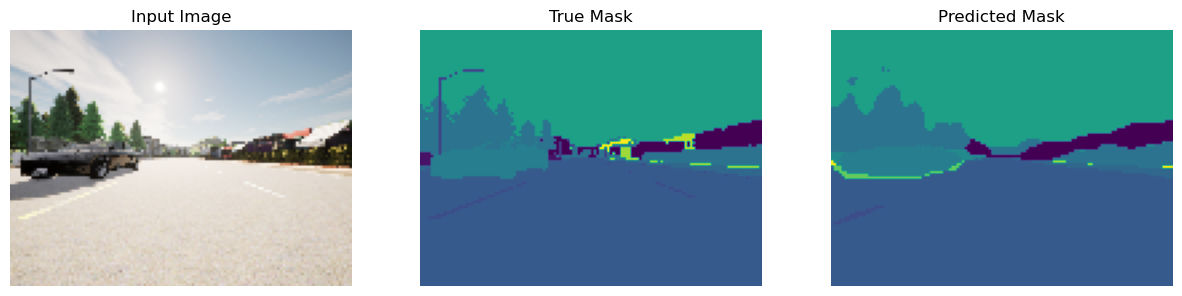

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step


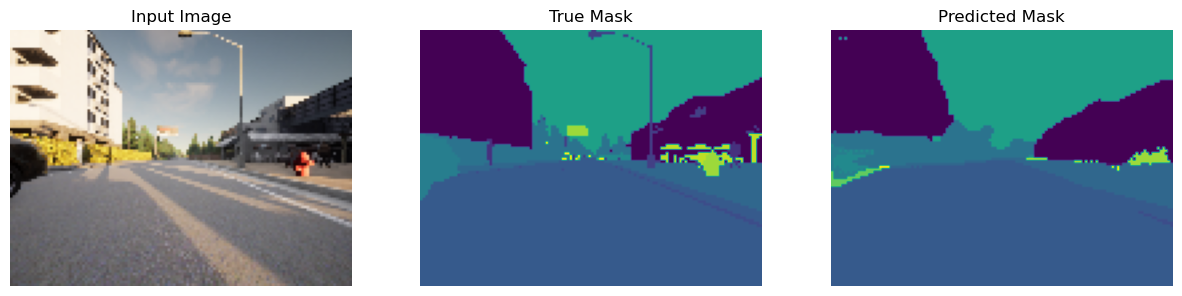

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step


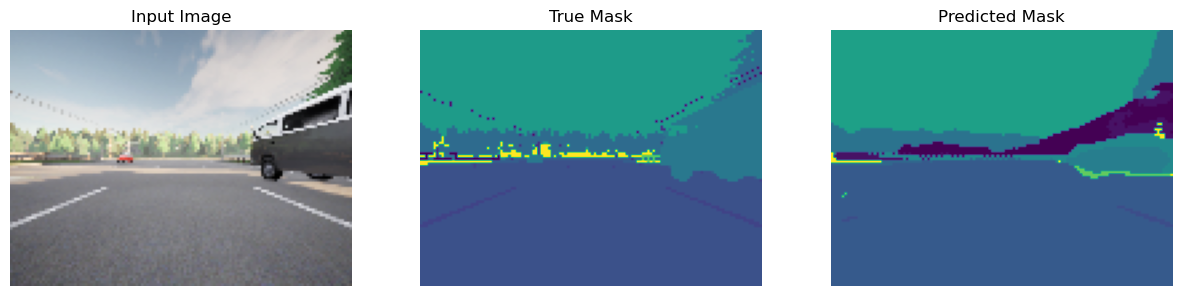

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step


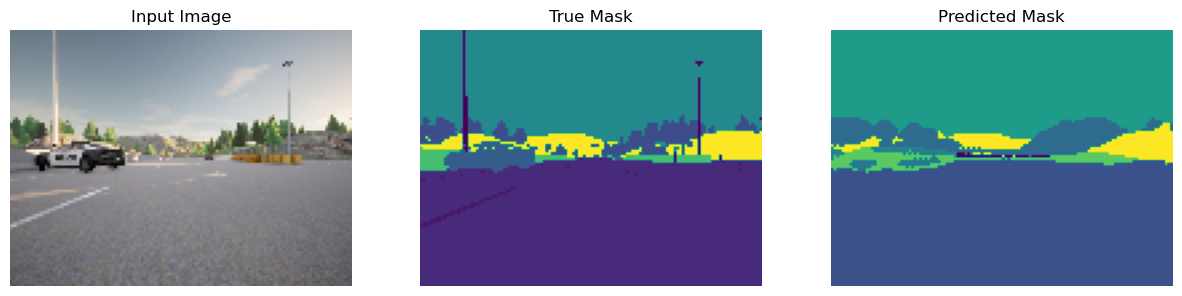

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step


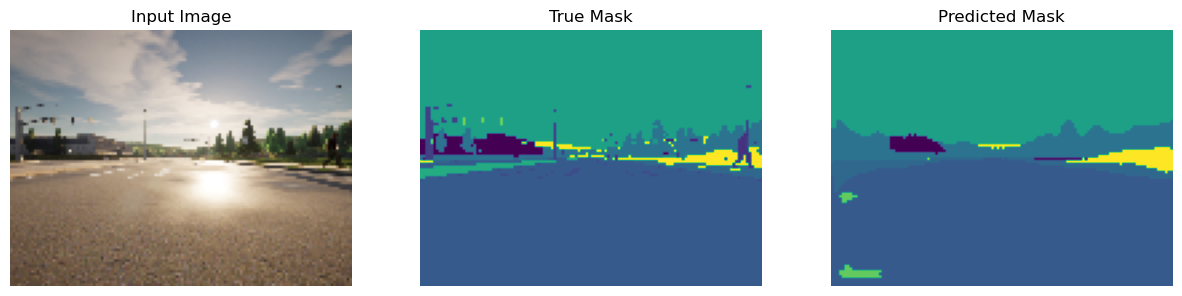

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step


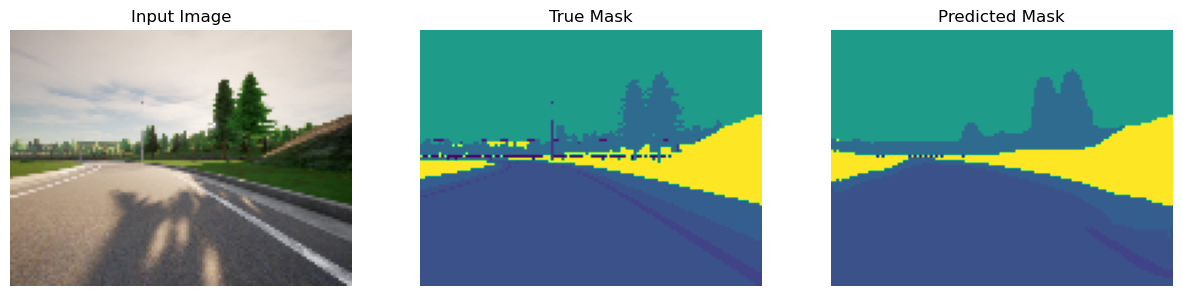

2024-05-05 18:46:23.428603: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [29]:
show_predictions(test_dataset, 6)

In [20]:
def fcn_model(input_size, n_filters, n_classes):
    inputs = Input(shape=input_size)
    # Contracting path
    c1 = Conv2D(n_filters, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(n_filters, (3, 3), activation='relu', padding='same')(c1)
    c1 = Dropout(0.3)(c1)  # Add dropout
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(n_filters * 2, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(n_filters * 2, (3, 3), activation='relu', padding='same')(c2)
    c2 = Dropout(0.3)(c2)  # Add dropout
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(n_filters * 4, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(n_filters * 4, (3, 3), activation='relu', padding='same')(c3)
    c3 = Dropout(0.3)(c3)  # Add dropout
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(n_filters * 8, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(n_filters * 8, (3, 3), activation='relu', padding='same')(c4)
    c4 = Dropout(0.3)(c4)  # Add dropout
    p4 = MaxPooling2D((2, 2))(c4)

    # Expanding Path
    u1 = Conv2DTranspose(n_filters * 8, (3, 3), strides=2, padding='same')(p4)
    c5 = Conv2D(n_filters * 8, (3, 3), activation='relu', padding='same')(u1)

    u2 = Conv2DTranspose(n_filters * 4, (3, 3), strides=2, padding='same')(c5)
    c6 = Conv2D(n_filters * 4, (3, 3), activation='relu', padding='same')(u2)

    u3 = Conv2DTranspose(n_filters * 2, (3, 3), strides=2, padding='same')(c6)
    c7 = Conv2D(n_filters * 2, (3, 3), activation='relu', padding='same')(u3)

    u4 = Conv2DTranspose(n_filters, (3, 3), strides=2, padding='same')(c7)
    c8 = Conv2D(n_filters, (3, 3), activation='relu', padding='same')(u4)

    # Output Layer
    outputs = Conv2D(n_classes, (1, 1), padding='same')(c8)

    
    return tf.keras.Model(inputs=inputs, outputs=outputs)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

In [21]:
fcn = fcn_model((96, 128, 3), 32, 23)
fcn.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 128, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 96, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 96, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 48, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 24, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 12, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 24, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 48, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 48, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,934,231 (11.19 MB)

 Trainable params: 2,934,231 (11.19 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
fcn.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [28]:
train_dataset = train_processed_image_ds.cache().shuffle(500).batch(32)
fcn_model_history = fcn.fit(train_dataset, epochs=40)

Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 847ms/step - accuracy: 0.7768 - loss: 0.7320
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 830ms/step - accuracy: 0.7759 - loss: 0.7108
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 863ms/step - accuracy: 0.7746 - loss: 0.7138
Epoch 4/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 950ms/step - accuracy: 0.7779 - loss: 0.7055
Epoch 5/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 990ms/step - accuracy: 0.7767 - loss: 0.6975
Epoch 6/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 945ms/step - accuracy: 0.7781 - loss: 0.6893
Epoch 7/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 907ms/step - accuracy: 0.7789 - loss: 0.6892
Epoch 8/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 913ms/step - accuracy: 0.7842 - loss: 0.6803
Epoch 9/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 934ms/step - accuracy: 0.7994 - loss: 0.6243
Epoch 10/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8013 - loss: 0.6118
Epoch 11/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 995ms/step - accuracy: 0.7936 - loss: 0.6806
Epoch 12/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 9

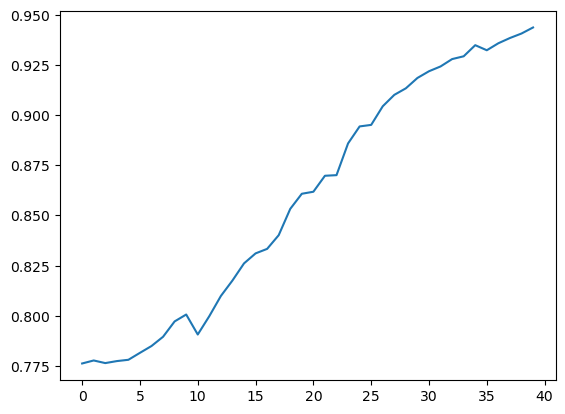

In [30]:
plt.plot(fcn_model_history.history["accuracy"])

In [31]:
test_dataset = test_processed_image_ds.cache().batch(32)
test_loss, test_accuracy = fcn.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - accuracy: 0.9000 - loss: 0.3223
Test Loss: 0.31653696298599243
Test Accuracy: 0.9014189839363098


In [32]:
def show_fcn_predictions(dataset, num):
    for image, mask in dataset.take(num):
            pred_mask = fcn.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


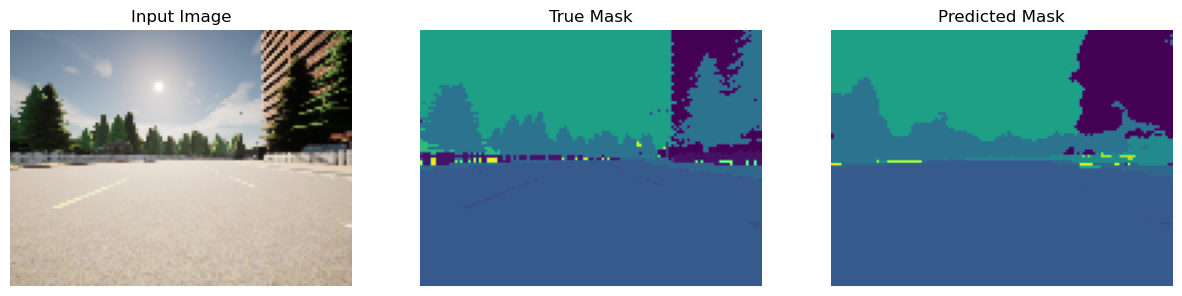

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


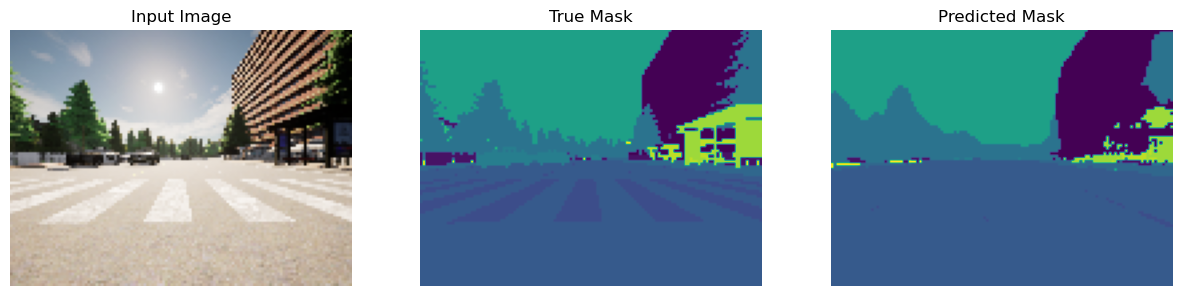

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


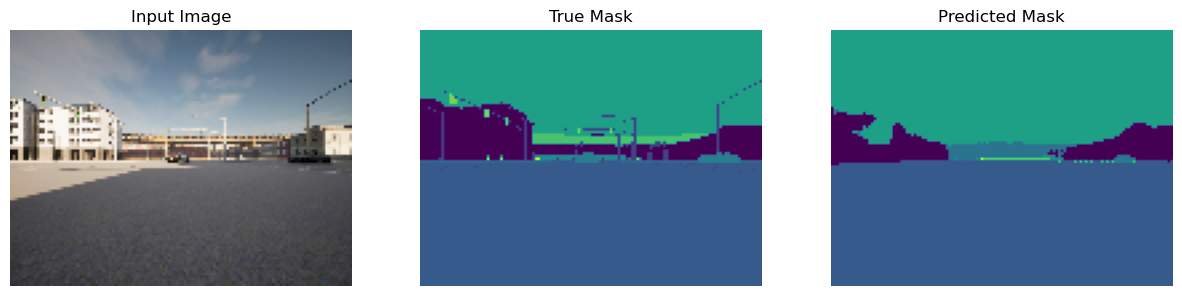

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


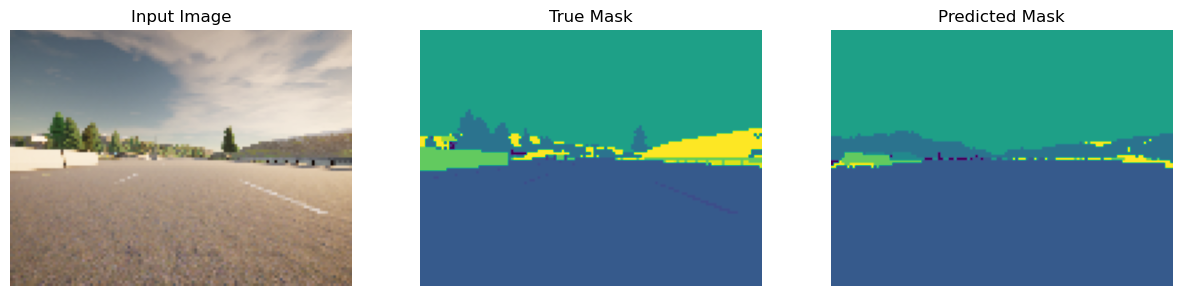

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step


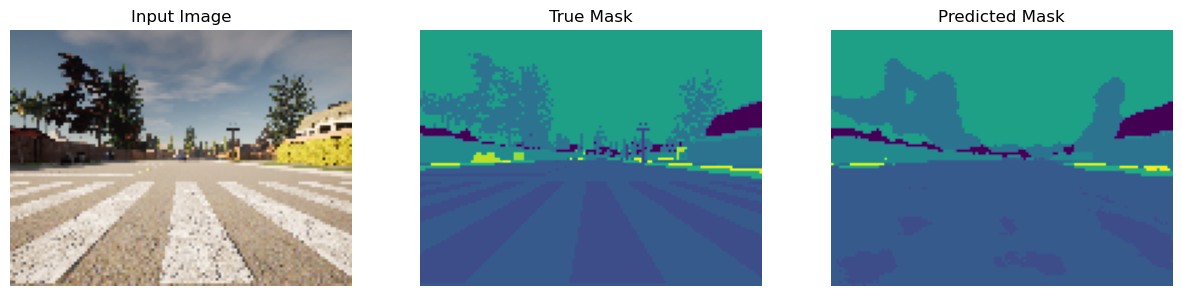

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


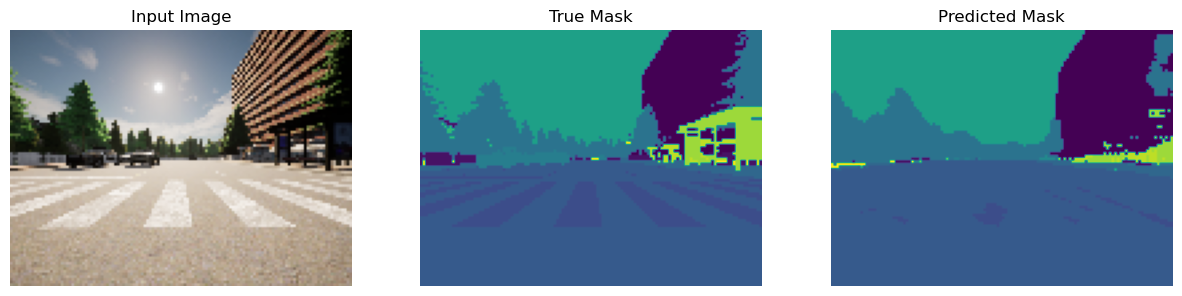

2024-05-05 18:50:30.810150: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [33]:
show_fcn_predictions(train_dataset, 6)